In [17]:
# Task 1.
# Текстурные характеристики:
#  - Реализуйте подсчет гистограммы 
#  - Реализуйте рассчет текстурных характеристик Laws 
#  - Реализуйте расчет текстурных характеристик на основе матрицы взаимной встречаемости GLCM
# Для каждого случая: выполните тренировку классификатора (knn, svm, trees)
# Решите задачу сегментации данных на основе классификации изображений каждым методом.
# Выполните ручную разметку изображений на регионы.
# Сравните результат полученной классификации и размеченной.

In [18]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [19]:
# ============================================
# 1. Функции для извлечения текстурных признаков
# ============================================

def extract_histogram_features(image):
    """Подсчет гистограммы"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

def extract_laws_features(image):
    """Расчет текстурных характеристик Laws"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    gray = gray.astype(np.float32)
    
    L5 = np.array([1, 4, 6, 4, 1])
    E5 = np.array([-1, -2, 0, 2, 1])
    S5 = np.array([-1, 0, 2, 0, -1])
    W5 = np.array([-1, 2, 0, -2, 1])
    R5 = np.array([1, -4, 6, -4, 1])
    
    kernels = [L5, E5, S5, W5, R5]
    features = []
    
    for i in range(5):
        for j in range(5):
            kernel_2d = np.outer(kernels[i], kernels[j])
            filtered = cv2.filter2D(gray, -1, kernel_2d)
            features.append(np.mean(filtered))
            features.append(np.std(filtered))
    
    return np.array(features)

def extract_glcm_features(image):
    """Расчет текстурных характеристик на основе GLCM"""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    gray = (gray / 32).astype(np.uint8)
    
    glcm = np.zeros((8, 8), dtype=np.float32)
    h, w = gray.shape
    
    for i in range(h):
        for j in range(w-1):
            glcm[gray[i, j], gray[i, j+1]] += 1
    
    if glcm.sum() > 0:
        glcm = glcm / glcm.sum()
    
    features = []
    
    contrast = 0
    for i in range(8):
        for j in range(8):
            contrast += glcm[i, j] * (i - j) ** 2
    features.append(contrast)
    
    energy = np.sum(glcm ** 2)
    features.append(energy)
    
    entropy = 0
    for i in range(8):
        for j in range(8):
            if glcm[i, j] > 0:
                entropy -= glcm[i, j] * np.log(glcm[i, j] + 1e-10)
    features.append(entropy)
    
    return np.array(features)



In [20]:
# ============================================
# 2. Загрузка данных
# ============================================

def load_all_data():
    """Загрузка всего датасета"""
    data_path = "./KTH_TIPS"
    
    images = []
    labels = []
    label_names = []
    
    classes = sorted([d for d in os.listdir(data_path) 
                     if os.path.isdir(os.path.join(data_path, d))])
    
    print(f"Классов: {len(classes)}")
    
    for class_idx, class_name in enumerate(classes):
        label_names.append(class_name)
        class_path = os.path.join(data_path, class_name)
        
        image_files = []
        for ext in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif']:
            files = [f for f in os.listdir(class_path) if f.lower().endswith(ext)]
            image_files.extend(files)
        
        for img_file in image_files:
            img_path = os.path.join(class_path, img_file)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.resize(img, (128, 128))
                images.append(img)
                labels.append(class_idx)
    
    return np.array(images), np.array(labels), label_names



In [21]:
# ============================================
# 3. Классификация
# ============================================

def train_classifiers(features, labels):
    """Тренировка классификаторов"""
    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.2, random_state=42
    )
    
    results = {}
    
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)
    knn_pred = knn.predict(X_test)
    knn_acc = accuracy_score(y_test, knn_pred)
    results['kNN'] = {'classifier': knn, 'accuracy': knn_acc}
    
    svm = SVC(kernel='rbf')
    svm.fit(X_train, y_train)
    svm_pred = svm.predict(X_test)
    svm_acc = accuracy_score(y_test, svm_pred)
    results['SVM'] = {'classifier': svm, 'accuracy': svm_acc}
    
    tree = DecisionTreeClassifier()
    tree.fit(X_train, y_train)
    tree_pred = tree.predict(X_test)
    tree_acc = accuracy_score(y_test, tree_pred)
    results['Tree'] = {'classifier': tree, 'accuracy': tree_acc}
    
    return results, X_test, y_test



In [22]:
# ============================================
# 4. Сегментация
# ============================================

def segment_image(image, feature_extractor, classifier):
    """Сегментация изображения"""
    h, w = image.shape[:2]
    window_size = 64
    step = 32
    
    segmented = np.zeros((h, w, 3), dtype=np.uint8)
    
    colors = [
        [255, 0, 0], [0, 255, 0], [0, 0, 255],
        [255, 255, 0], [255, 0, 255], [0, 255, 255],
        [128, 0, 0], [0, 128, 0], [0, 0, 128], [128, 128, 0]
    ]
    
    for y in range(0, h - window_size + 1, step):
        for x in range(0, w - window_size + 1, step):
            window = image[y:y+window_size, x:x+window_size]
            features = feature_extractor(window)
            label = classifier.predict([features])[0]
            color_idx = label % len(colors)
            segmented[y:y+step, x:x+step] = colors[color_idx]
    
    return segmented

def manual_segmentation(image):
    """Ручная разметка"""
    h, w = image.shape[:2]
    manual = np.zeros((h, w, 3), dtype=np.uint8)
    
    h_mid = h // 2
    w_mid = w // 2
    
    colors = [[255, 0, 0], [0, 255, 0], [0, 0, 255], [255, 255, 0]]
    
    manual[:h_mid, :w_mid] = colors[0]
    manual[:h_mid, w_mid:] = colors[1]
    manual[h_mid:, :w_mid] = colors[2]
    manual[h_mid:, w_mid:] = colors[3]
    
    return manual



In [23]:
# ============================================
# 5. Сравнение
# ============================================

def compare_segmentation(original, auto_segmented, manual_segmented, title):
    """Сравнение сегментаций"""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Оригинал')
    axes[0].axis('off')
    
    axes[1].imshow(auto_segmented)
    axes[1].set_title(title)
    axes[1].axis('off')
    
    axes[2].imshow(manual_segmented)
    axes[2].set_title('Ручная')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()



In [24]:
# ============================================
# 6. Основная программа
# ============================================

def main():
    print("=" * 50)
    print("ТЕКСТУРНАЯ КЛАССИФИКАЦИЯ И СЕГМЕНТАЦИЯ")
    print("=" * 50)
    
    # 1. Загрузка данных
    print("\nЗагрузка датасета...")
    images, labels, label_names = load_all_data()
    print(f"Изображений: {len(images)}")
    
    # 2. Методы извлечения признаков
    methods = {
        'Гистограмма': extract_histogram_features,
        'Laws': extract_laws_features,
        'GLCM': extract_glcm_features
    }
    
    all_results = {}
    
    # 3. Для каждого метода
    for method_name, feature_func in methods.items():
        print(f"\n{method_name}:")
        
        # Извлечение признаков
        print("  Извлечение признаков...")
        features_list = []
        for img in images:
            features = feature_func(img)
            features_list.append(features)
        
        features_array = np.array(features_list)
        
        # Тренировка классификаторов
        print("  Тренировка...")
        results, X_test, y_test = train_classifiers(features_array, labels)
        all_results[method_name] = results
        
        # Результаты
        print("  Результаты:")
        for clf_name, result in results.items():
            print(f"    {clf_name}: {result['accuracy']:.3f}")
        
        # Лучший классификатор
        best_clf_name = max(results, key=lambda x: results[x]['accuracy'])
        best_result = results[best_clf_name]
        
        # Сегментация
        if len(y_test) > 0:
            # Берем одно тестовое изображение
            test_idx = 0
            for i in range(len(labels)):
                if labels[i] == y_test[test_idx]:
                    img_idx = i
                    break
            
            original_img = images[img_idx]
            
            auto_segmented = segment_image(
                original_img,
                feature_func,
                best_result['classifier']
            )
            
            manual_segmented = manual_segmentation(original_img)
            
            compare_segmentation(
                original_img,
                auto_segmented,
                manual_segmented,
                f"{method_name} + {best_clf_name}"
            )
    
    # 4. Итоговое сравнение
    print(f"\n{'='*50}")
    print("ИТОГИ:")
    print(f"{'='*50}")
    
    print("\nЛучшие результаты:")
    for method_name, results in all_results.items():
        best_acc = max([results[clf]['accuracy'] for clf in results])
        best_clf = max(results, key=lambda x: results[x]['accuracy'])
        print(f"  {method_name:15} -> {best_clf:10}: {best_acc:.3f}")
    
    # 5. График сравнения
    fig, ax = plt.subplots(figsize=(10, 5))
    
    methods_list = list(all_results.keys())
    classifiers = ['kNN', 'SVM', 'Tree']
    
    x = np.arange(len(methods_list))
    width = 0.25
    
    for i, clf in enumerate(classifiers):
        accuracies = []
        for method in methods_list:
            if clf in all_results[method]:
                acc = all_results[method][clf]['accuracy']
                accuracies.append(acc)
            else:
                accuracies.append(0)
        
        ax.bar(x + i*width - width, accuracies, width, label=clf)
    
    ax.set_xlabel('Метод')
    ax.set_ylabel('Точность')
    ax.set_title('Сравнение методов')
    ax.set_xticks(x)
    ax.set_xticklabels(methods_list)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()




ТЕКСТУРНАЯ КЛАССИФИКАЦИЯ И СЕГМЕНТАЦИЯ

Загрузка датасета...
Классов: 10
Изображений: 810

Гистограмма:
  Извлечение признаков...
  Тренировка...
  Результаты:
    kNN: 0.673
    SVM: 0.574
    Tree: 0.660


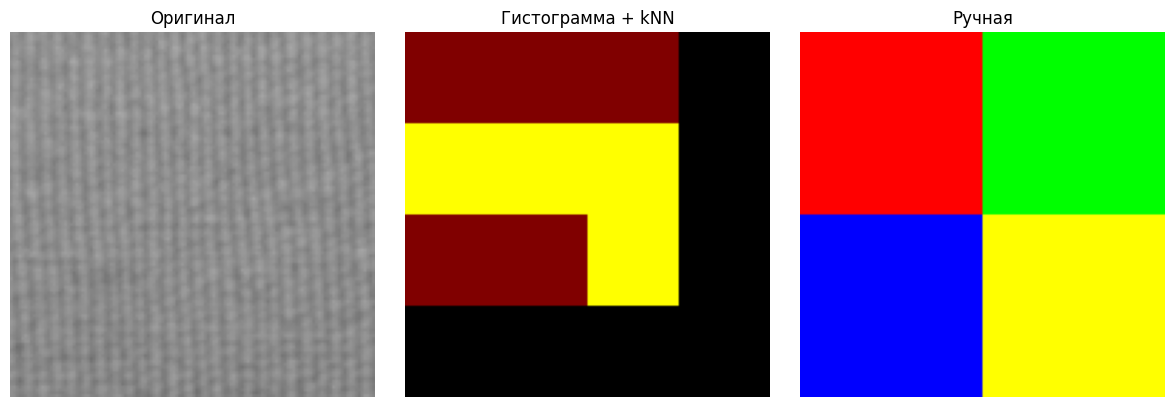


Laws:
  Извлечение признаков...
  Тренировка...
  Результаты:
    kNN: 0.735
    SVM: 0.525
    Tree: 0.698


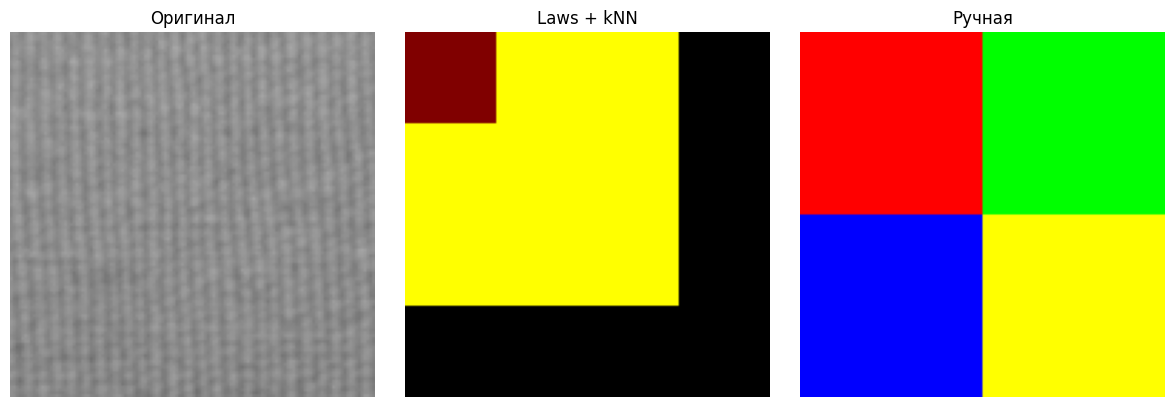


GLCM:
  Извлечение признаков...
  Тренировка...
  Результаты:
    kNN: 0.444
    SVM: 0.370
    Tree: 0.488


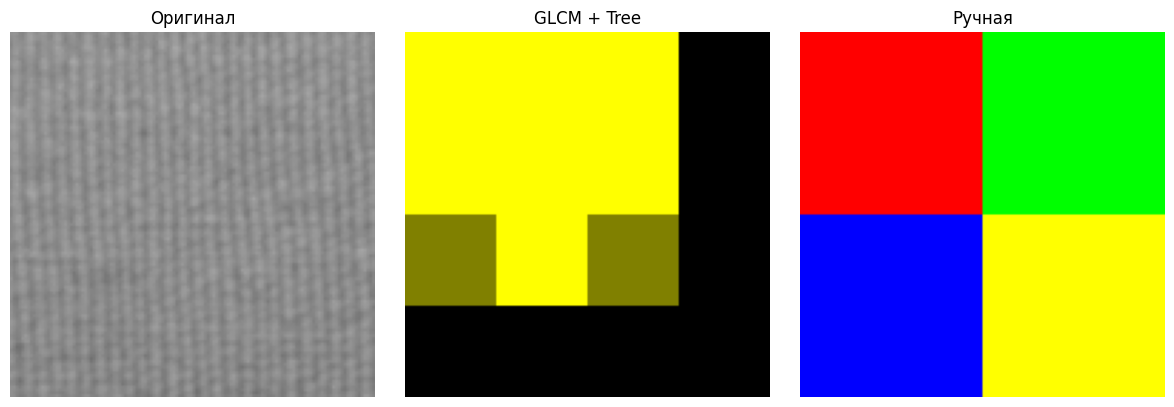


ИТОГИ:

Лучшие результаты:
  Гистограмма     -> kNN       : 0.673
  Laws            -> kNN       : 0.735
  GLCM            -> Tree      : 0.488


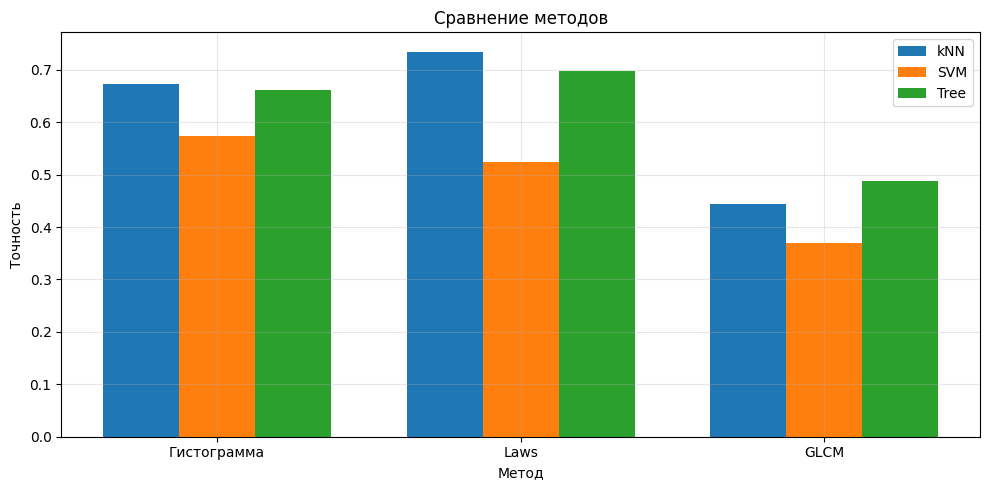

In [25]:
if __name__ == "__main__":
    main()